In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

In [184]:
input_file = 'data-19.txt'
data = pd.read_csv(input_file, delim_whitespace=True, header=None, names=['t', 'y'])
t = data['t'].values
y = data['y'].values

In [207]:
def model1(t, alpha0, alpha1, alpha2, beta1, beta2):
    return alpha0 + alpha1 * np.exp(beta1 * t) + alpha2 * np.exp(beta2 * t)

def objective_function(params, t, y):
    alpha0, alpha1, alpha2, beta1, beta2 = params
    return np.sum((y - model1(t, alpha0, alpha1, alpha2, beta1, beta2))**2)

def gradient_function(params, t, y):
    alpha0, alpha1, alpha2, beta1, beta2 = params
    grad_alpha0 = -2 * np.sum(y - model1(t, alpha0, alpha1, alpha2, beta1, beta2))
    grad_alpha1 = -2 * np.sum((y - model1(t, alpha0, alpha1, alpha2, beta1, beta2)) * np.exp(beta1 * t))
    grad_alpha2 = -2 * np.sum((y - model1(t, alpha0, alpha1, alpha2, beta1, beta2)) * np.exp(beta2 * t))
    grad_beta1 = -2 * np.sum((y - model1(t, alpha0, alpha1, alpha2, beta1, beta2)) * alpha1 * t * np.exp(beta1 * t))
    grad_beta2 = -2 * np.sum((y - model1(t, alpha0, alpha1, alpha2, beta1, beta2)) * alpha2 * t * np.exp(beta2 * t))
    return np.array([grad_alpha0, grad_alpha1, grad_alpha2, grad_beta1, grad_beta2])

def _calculate_hessian(params, t, y):
    alpha0, alpha1, alpha2, beta1, beta2 = params
    h11 = 2 * len(t)
    h12 = 2 * np.sum(np.exp(beta1 * t))
    h13 = 2 * np.sum(np.exp(beta2 * t))
    h14 = 2 * np.sum(alpha1 * t * np.exp(beta1 * t))
    h15 = 2 * np.sum(alpha2 * t * np.exp(beta2 * t))
    h22 = 2 * np.sum(t**2 * np.exp(2 * beta1 * t))
    h23 = 2 * np.sum(t * np.exp((beta1 + beta2) * t))
    h24 = 2 * np.sum(alpha1 * t**2 * np.exp(2 * beta1 * t))
    h25 = 2 * np.sum(alpha2 * t**2 * np.exp((beta1 + beta2) * t))
    h33 = 2 * np.sum(t**2 * np.exp(2 * beta2 * t))
    h34 = 2 * np.sum(alpha1 * t**2 * np.exp((beta1 + beta2) * t))
    h35 = 2 * np.sum(alpha2 * t**2 * np.exp(2 * beta2 * t))
    h44 = 2 * np.sum(alpha1**2 * t**2 * np.exp(2 * beta1 * t))
    h45 = 2 * np.sum(alpha1 * alpha2 * t**2 * np.exp((beta1 + beta2) * t))
    h55 = 2 * np.sum(alpha2**2 * t**2 * np.exp(2 * beta2 * t))
    hessian = np.array([[h11, h12, h13, h14, h15],
                        [h12, h22, h23, h24, h25],
                        [h13, h23, h33, h34, h35],
                        [h14, h24, h34, h44, h45],
                        [h15, h25, h35, h45, h55]])
    return hessian

def levenberg_marquardt_1(t, y, initial_params, max_iter=50000, tol=1e-2, mu=1.0):
    params = initial_params
    for i in range(max_iter):
        gradient = gradient_function(params, t, y)
        hessian = _calculate_hessian(params, t, y)
        
        diag_hessian = np.diag(hessian)
        damping = mu * np.max(diag_hessian)
        hessian_lm = hessian + damping * np.eye(len(params))
        
        try:
            delta_params = np.linalg.solve(hessian_lm, gradient)
            params = params - delta_params
        except np.linalg.LinAlgError:
            print(f"Levenberg-Marquardt iteration {i}: Hessian matrix is not invertible.")
            mu *= 10 
            continue
        
        if np.linalg.norm(gradient) < tol:
            print(f"Levenberg-Marquardt converged in {i+1} iterations.")
            return params
        
        # Update the damping factor
        if np.linalg.norm(delta_params) < tol:
            mu /= 10
        else:
            mu *= 10
    
    print("Levenberg-Marquardt did not converge.")
    return params
initial_guess_1 = [0,-1,-0.1,1,-0.05]
params_1 = levenberg_marquardt_1(t, y, initial_guess_1)
print(params_1)

Levenberg-Marquardt converged in 19251 iterations.
[ 2.61188295  0.30886063 -4.28813967  0.56238717 -1.41372342]


In [ ]:
def model2(t, alpha0, alpha1, beta0, beta1):
    return alpha0 + alpha1 * (t ** beta0) / (1 + beta1 * t)

def objective_function(params, t, y):
    alpha0, alpha1, beta0, beta1 = params
    return np.sum((y - model2(t, alpha0, alpha1, beta0, beta1))**2)

def gradient_function(params, t, y):
    alpha0, alpha1, beta0, beta1 = params

    epsilon = 1e-10

    # Safely compute the gradient with respect to each parameter
    grad_alpha0 = -2 * np.sum((y - model2(t, alpha0, alpha1, beta0, beta1)))
    grad_alpha1 = -2 * np.sum((y - model2(t, alpha0, alpha1, beta0, beta1)) * (t ** beta0) / (1 + beta1 * t))
    
    # Safely compute the gradient with respect to beta0
    grad_beta0 = -2 * np.sum((y - model2(t, alpha0, alpha1, beta0, beta1)) * alpha1 * (t ** beta0) * 
                             np.log(np.clip(t, epsilon, None)) / (1 + beta1 * t))

    grad_beta1 = -2 * np.sum((y - model2(t, alpha0, alpha1, beta0, beta1)) * alpha1 * (t ** beta0) / ((1 + beta1 * t) ** 2))
    
    return np.array([grad_alpha0, grad_alpha1, grad_beta0, grad_beta1])


def _calculate_hessian(params, t, y):
    alpha0, alpha1, beta0, beta1 = params
    epsilon = 1e-10
    
    h11 = 2 * len(t)
    h12 = 2 * np.sum((t ** beta0) / (1 + beta1 * t))
    
    h13 = 2 * np.sum(alpha1 * (t ** beta0) * np.log(np.clip(t, epsilon, None)) / (1 + beta1 * t))
    h14 = 2 * np.sum(alpha1 * (t ** beta0) / ((1 + beta1 * t) ** 2))
    
    h22 = 2 * np.sum((t ** (2 * beta0)) / ((1 + beta1 * t) ** 2))
    
    h23 = 2 * np.sum(alpha1 * (t ** (2 * beta0)) * np.log(np.clip(t, epsilon, None)) / ((1 + beta1 * t) ** 2))
    h24 = 2 * np.sum(alpha1 * (t ** (2 * beta0)) / ((1 + beta1 * t) ** 3))
    
    h33 = 2 * np.sum(alpha1**2 * (t ** (2 * beta0)) * np.log(np.clip(t, epsilon, None))**2 / ((1 + beta1 * t) ** 2))
    h34 = 2 * np.sum(alpha1**2 * (t ** (2 * beta0)) * np.log(np.clip(t, epsilon, None)) / ((1 + beta1 * t) ** 3))
    h44 = 2 * np.sum(alpha1**2 * (t ** (2 * beta0)) / ((1 + beta1 * t) ** 4))
    
    hessian = np.array([[h11, h12, h13, h14],
                        [h12, h22, h23, h24],
                        [h13, h23, h33, h34],
                        [h14, h24, h34, h44]])
    
    return hessian

def levenberg_marquardt_2(t, y, initial_params, max_iter=200000, tol=1e-2, mu=1.0):
    params = initial_params
    for i in range(max_iter):
        gradient = gradient_function(params, t, y)
        hessian = _calculate_hessian(params, t, y)
        
        # Levenberg-Marquardt update
        diag_hessian = np.diag(hessian)
        damping = mu * np.max(diag_hessian)
        hessian_lm = hessian + damping * np.eye(len(params))
        
        try:
            delta_params = np.linalg.solve(hessian_lm, gradient)
            params = params - delta_params
        except np.linalg.LinAlgError:
            print(f"Levenberg-Marquardt iteration {i}: Hessian matrix is not invertible.")
            mu *= 10 
            continue
        
        if np.linalg.norm(gradient) < tol:
            print(f"Levenberg-Marquardt converged in {i+1} iterations.")
            return params
        
        if np.linalg.norm(delta_params) < tol:
            mu /= 10
        else:
            mu *= 10
    
    print("Levenberg-Marquardt did not converge.")
    return params

# Example usage:
initial_guess_2 = [0, 1, 1.05, 0.5]
params_2 = levenberg_marquardt_2(t, y, initial_guess_2)
print(params_2)


Levenberg-Marquardt did not converge.
[1.96332656e-02 2.06372551e+03 2.14028768e+00 1.32985691e+03]


In [226]:
def model3(t, beta0, beta1, beta2, beta3, beta4):
    return beta0 + beta1 * t + beta2 * t**2 + beta3 * t**3 + beta4 * t**4

def objective_function(params, t, y):
    beta0, beta1, beta2, beta3, beta4 = params
    return np.sum((y - model3(t, beta0, beta1, beta2, beta3, beta4))**2)

def gradient_function(params, t, y):
    beta0, beta1, beta2, beta3, beta4 = params
    grad_beta0 = -2 * np.sum(y - model3(t, beta0, beta1, beta2, beta3, beta4))
    grad_beta1 = -2 * np.sum((y - model3(t, beta0, beta1, beta2, beta3, beta4)) * t)
    grad_beta2 = -2 * np.sum((y - model3(t, beta0, beta1, beta2, beta3, beta4)) * t**2)
    grad_beta3 = -2 * np.sum((y - model3(t, beta0, beta1, beta2, beta3, beta4)) * t**3)
    grad_beta4 = -2 * np.sum((y - model3(t, beta0, beta1, beta2, beta3, beta4)) * t**4)
    return np.array([grad_beta0, grad_beta1, grad_beta2, grad_beta3, grad_beta4])

def _calculate_hessian(params, t, y):
    beta0, beta1, beta2, beta3, beta4 = params
    h11 = 2 * len(t)
    h12 = 2 * np.sum(t)
    h13 = 2 * np.sum(t**2)
    h14 = 2 * np.sum(t**3)
    h15 = 2 * np.sum(t**4)
    h22 = 2 * np.sum(t**2)
    h23 = 2 * np.sum(t**3)
    h24 = 2 * np.sum(t**4)
    h25 = 2 * np.sum(t**5)
    h33 = 2 * np.sum(t**4)
    h34 = 2 * np.sum(t**5)
    h35 = 2 * np.sum(t**6)
    h44 = 2 * np.sum(t**6)
    h45 = 2 * np.sum(t**7)
    h55 = 2 * np.sum(t**8)
    hessian = np.array([[h11, h12, h13, h14, h15],
                        [h12, h22, h23, h24, h25],
                        [h13, h23, h33, h34, h35],
                        [h14, h24, h34, h44, h45],
                        [h15, h25, h35, h45, h55]])
    return hessian

def levenberg_marquardt_3(t, y, initial_params, max_iter=50000, tol=1e-2, mu=1.0):
    params = initial_params
    for i in range(max_iter):
        gradient = gradient_function(params, t, y)
        hessian = _calculate_hessian(params, t, y)
        
        # Levenberg-Marquardt update
        diag_hessian = np.diag(hessian)
        damping = mu * np.max(diag_hessian)
        hessian_lm = hessian + damping * np.eye(len(params))
        
        try:
            delta_params = np.linalg.solve(hessian_lm, gradient)
            params = params - delta_params
        except np.linalg.LinAlgError:
            print(f"Levenberg-Marquardt iteration {i}: Hessian matrix is not invertible.")
            mu *= 10  # Increase the damping factor
            continue
        
        if np.linalg.norm(gradient) < tol:
            print(f"Levenberg-Marquardt converged in {i+1} iterations.")
            return params
        
        # Update the damping factor
        if np.linalg.norm(delta_params) < tol:
            mu /= 10
        else:
            mu *= 10
    
    print("Levenberg-Marquardt did not converge.")
    return params

initial_guess_3 = [0, 1, 0.1, 0.01, 0.001]
params_3 = levenberg_marquardt_3(t, y, initial_guess_3)
print(params_3)

Levenberg-Marquardt converged in 581 iterations.
[-1.33087634  5.65628326 -1.92366192 -1.38228017  1.10337376]


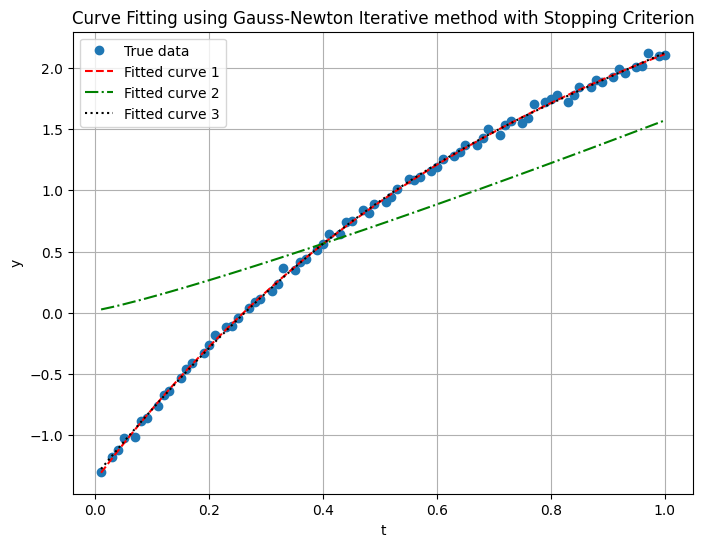

In [227]:
plt.figure(figsize=(8, 6))
plt.plot(t, y,'o', label="True data")  # True data points
y_fit_1 = model1(t, *params_1)  # Fitted curve
y_fit_2 = model2(t, *params_2)
y_fit_3 = model3(t, *params_3)

plt.plot(t, y_fit_1, linestyle = '--', label="Fitted curve 1", color = 'red')  # Fitted curve
plt.plot(t, y_fit_2, linestyle = '-.', label="Fitted curve 2", color = 'green')
plt.plot(t, y_fit_3, linestyle = ':', label="Fitted curve 3", color = 'black')
plt.xlabel("t")
plt.ylabel("y")



plt.title("Curve Fitting using Gauss-Newton Iterative method with Stopping Criterion")
plt.legend()
plt.grid(True)
plt.show()

In [211]:
def calculate_log_likelihood(y_true, y_pred):
    log_likelihood = 0
    for true, pred in zip(y_true, y_pred):
        # Avoid log(0) by adding a very small epsilon
        epsilon = 1e-10
        pred = max(min(pred, 1 - epsilon), epsilon)
        log_likelihood += true * math.log(pred) + (1 - true) * math.log(1 - pred)
    return log_likelihood

def calculate_aic(log_likelihood, num_params):
    return 2 * num_params - 2 * log_likelihood

In [212]:
log_likelihood1 = calculate_log_likelihood(y, y_fit_1)
log_likelihood2 = calculate_log_likelihood(y, y_fit_2)
log_likelihood3 = calculate_log_likelihood(y, y_fit_3)

k1 = 5
k2 = 4
k3 = 5

aic1 = calculate_aic(log_likelihood1, k1)
aic2 = calculate_aic(log_likelihood2, k2)
aic3 = calculate_aic(log_likelihood3, k3)

best_model = min((aic1, 'Model 1'), (aic2, 'Model 2'), (aic3, 'Model 3'), key=lambda x: x[0])
best_model

(-1527.2352860313538, 'Model 1')

In [213]:
def calculate_sigma_squared(y_true, y_pred, num_params):
    residuals = y_true - y_pred
    n = len(y_true)
    RSS = np.sum(residuals**2)
    sigma_squared = RSS / (n - num_params)
    return sigma_squared

def estimate_sigma_all_models(y, y_fit_1, y_fit_2, y_fit_3):
    sigma_sq = {
        'Model 1': calculate_sigma_squared(y, y_fit_1, 5),  # α₀, α₁, α₂, β₁, β₂
        'Model 2': calculate_sigma_squared(y, y_fit_2, 4),  # α₀, α₁, β₀, β₁
        'Model 3': calculate_sigma_squared(y, y_fit_3, 5)   # β₀, β₁, β₂, β₃, β₄
    }
    return sigma_sq

sigma_square = estimate_sigma_all_models(y,y_fit_1,y_fit_2,y_fit_3)
print(sigma_square)

{'Model 1': 0.0008259733230705312, 'Model 2': 0.3374847636478204, 'Model 3': 0.0008858572979071524}


In [214]:
res_1 = y-y_fit_1
sigma_squared_1 = np.sum(res_1**2) / (len(y) - 5)

res_2 = y-y_fit_2
sigma_squared_2 = np.sum(res_2**2) / (len(y) - 4)

res_3 = y-y_fit_3
sigma_squared_3 = np.sum(res_3**2) / (len(y) - 5)

In [215]:
def jacobian_model1(t, *params):
    alpha0, alpha1, beta1, alpha2, beta2 = params
    n = len(t)
    J = np.zeros((n, 5))
    J[:, 0] = 1                                # d/d(alpha0)
    J[:, 1] = np.exp(beta1 * t)                # d/d(alpha1)
    J[:, 2] = alpha1 * t * np.exp(beta1 * t)   # d/d(beta1)
    J[:, 3] = np.exp(beta2 * t)                # d/d(alpha2)
    J[:, 4] = alpha2 * t * np.exp(beta2 * t)   # d/d(beta2)
    return J

def jacobian_model2(t, *params):
    alpha0, alpha1, beta0, beta1 = params
    n = len(t)
    J = np.zeros((n, 4))
    
    # Partial derivatives
    denominator = (beta0 + beta1 * t)
    J[:, 0] = 1 / denominator                            # d/d(alpha0)
    J[:, 1] = t / denominator                            # d/d(alpha1)
    J[:, 2] = -(alpha0 + alpha1 * t) / (denominator**2)  # d/d(beta0)
    J[:, 3] = -t * (alpha0 + alpha1 * t) / (denominator**2)  # d/d(beta1)
    
    return J

def jacobian_model3(t, *params):
    beta0, beta1, beta2, beta3, beta4 = params
    n = len(t)
    J = np.zeros((n, 5))
    
    # Partial derivatives
    J[:, 0] = 1           # d/d(beta0)
    J[:, 1] = t           # d/d(beta1)
    J[:, 2] = t**2        # d/d(beta2)
    J[:, 3] = t**3        # d/d(beta3)
    J[:, 4] = t**4        # d/d(beta4)
    
    return J

In [216]:
def compute_confidence_intervals(model, jacobian_func, t, y, *params):
    y_pred = model(t, *params)
    residuals = y - y_pred
    sigma_squared = np.sum(residuals ** 2) / (len(y) - len(params))
    J = jacobian_func(t, *params)
    
    # Fisher Information Matrix
    fisher_info_matrix = (J.T @ J) / sigma_squared
    
    # Covariance Matrix
    covariance_matrix = np.linalg.inv(fisher_info_matrix)
    
    # Standard Errors
    standard_errors = np.sqrt(np.diag(covariance_matrix))
    
    # 95% Confidence Intervals
    z_score = 1.96
    confidence_intervals = [
        (param - z_score * se, param + z_score * se)
        for param, se in zip(params, standard_errors)
    ]
    
    return params, standard_errors, confidence_intervals

In [217]:
results = {
    "Model 1": compute_confidence_intervals(model1, jacobian_model1, t, y, *params_1),
    "Model 2": compute_confidence_intervals(model2, jacobian_model2, t, y, *params_2),
    "Model 3": compute_confidence_intervals(model3, jacobian_model3, t, y, *params_3)
}

# Print results for each model
for model_name, (params, std_errs, ci) in results.items():
    print(f"\nResults for {model_name}:")
    print("Fitted Parameters:", params)
    print("Standard Errors:", std_errs)
    print("95% Confidence Intervals:")
    for i, (lower, upper) in enumerate(ci):
        print(f"Param {i+1}: [{lower:.4f}, {upper:.4f}]")


Results for Model 1:
Fitted Parameters: (2.6118829512233463, 0.3088606317537685, -4.28813966957946, 0.5623871673481149, -1.4137234202184858)
Standard Errors: [ 0.51524957  1.94410652 11.34386901  1.45380585  5.70436729]
95% Confidence Intervals:
Param 1: [1.6020, 3.6218]
Param 2: [-3.5016, 4.1193]
Param 3: [-26.5221, 17.9458]
Param 4: [-2.2871, 3.4118]
Param 5: [-12.5943, 9.7668]

Results for Model 2:
Fitted Parameters: (0.06747156138010256, 700.5209328071396, 2.1475403550329513, 480.09430046439707)
Standard Errors: [nan nan nan nan]
95% Confidence Intervals:
Param 1: [nan, nan]
Param 2: [nan, nan]
Param 3: [nan, nan]
Param 4: [nan, nan]

Results for Model 3:
Fitted Parameters: (-1.330876339907816, 5.65628326221974, -1.9236619187677049, -1.3822801733908376, 1.103373764897893)
Standard Errors: [0.01853022 0.2496639  0.99295892 1.4680717  0.7189434 ]
95% Confidence Intervals:
Param 1: [-1.3672, -1.2946]
Param 2: [5.1669, 6.1456]
Param 3: [-3.8699, 0.0225]
Param 4: [-4.2597, 1.4951]
Para

C:\Users\iamma\AppData\Local\Temp\ipykernel_1184\2546909938.py:14: RuntimeWarning: invalid value encountered in sqrt
  standard_errors = np.sqrt(np.diag(covariance_matrix))


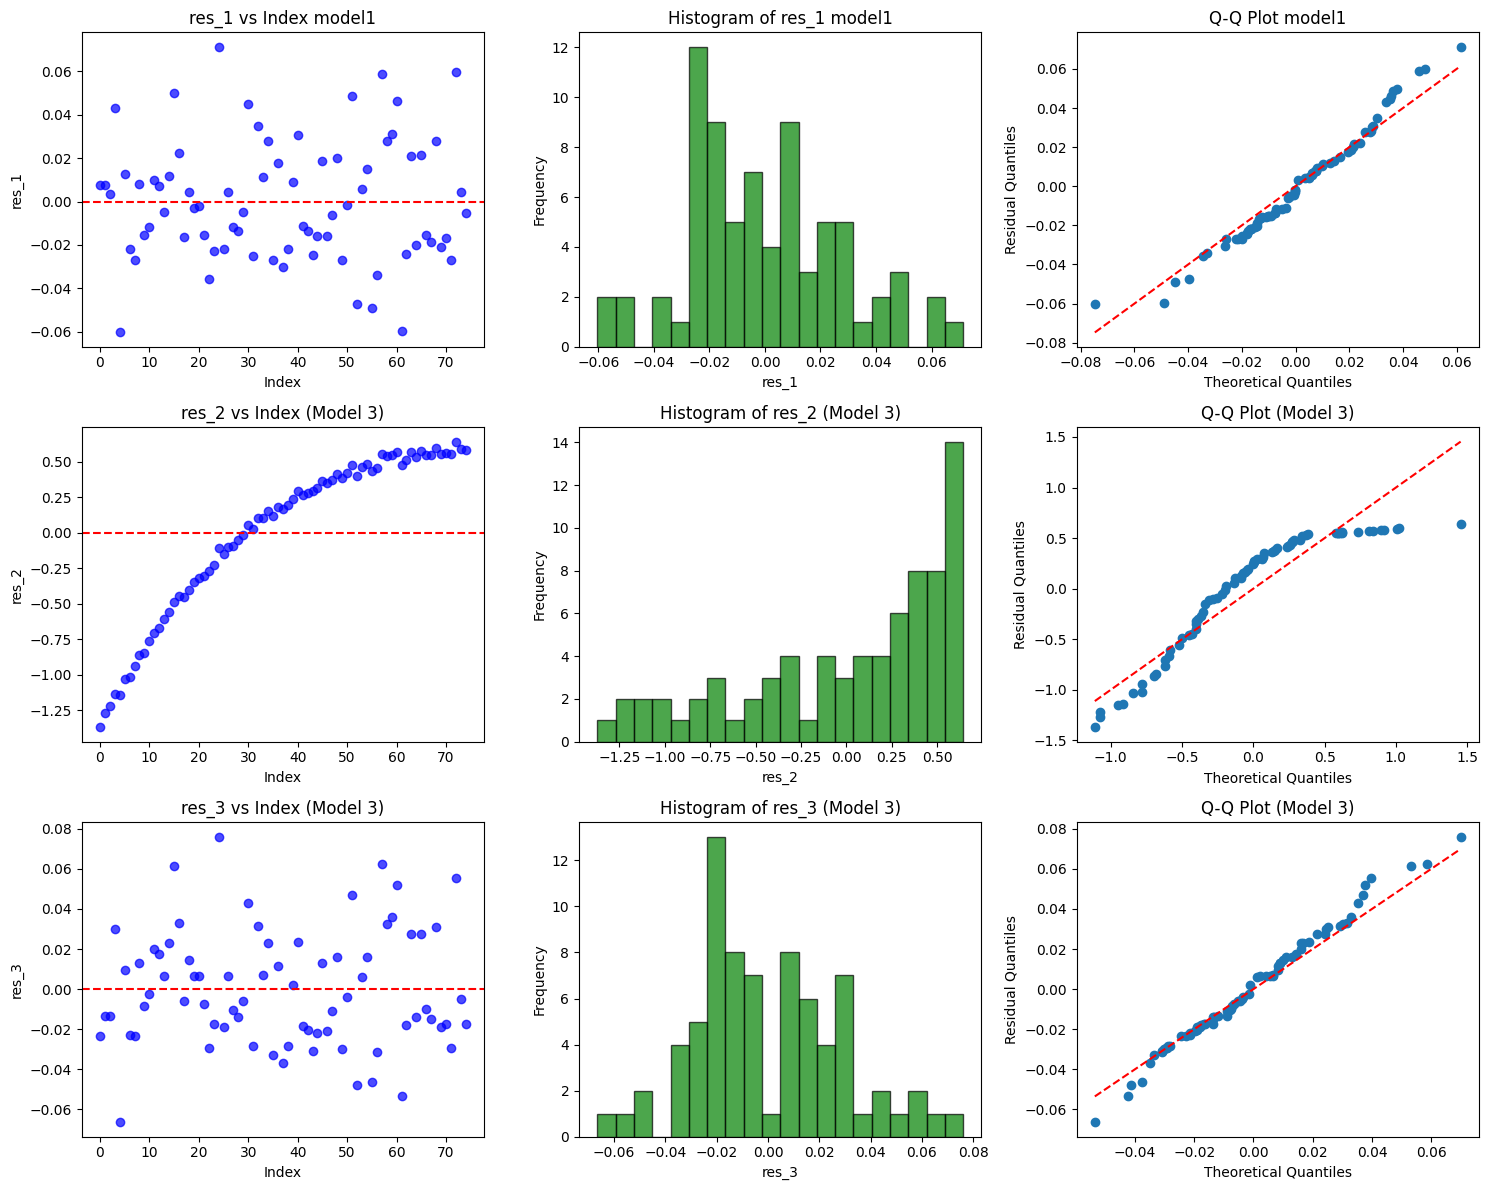

In [218]:
plt.figure(figsize=(15, 12))
plt.subplot(3, 3, 1)
plt.scatter(range(len(res_1)), res_1, alpha=0.7, color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title(f'res_1 vs Index model1')
plt.xlabel('Index')
plt.ylabel('res_1')

plt.subplot(3, 3, 2)
plt.hist(res_1, bins=20, alpha=0.7, edgecolor='black', color='green')
plt.title(f'Histogram of res_1 model1')
plt.xlabel('res_1')
plt.ylabel('Frequency')

plt.subplot(3, 3, 3)
sorted_res_1 = np.sort(res_1)
theoretical_quantiles = np.sort(np.random.normal(0, np.std(res_1), len(res_1)))
plt.plot(theoretical_quantiles, sorted_res_1, 'o')
plt.plot(theoretical_quantiles, theoretical_quantiles, 'r--')
plt.title(f'Q-Q Plot model1')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Residual Quantiles')

plt.subplot(3, 3, 4)
plt.scatter(range(len(res_2)), res_2, alpha=0.7, color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title(f'res_2 vs Index ({model_name})')
plt.xlabel('Index')
plt.ylabel('res_2')

plt.subplot(3, 3, 5)
plt.hist(res_2, bins=20, alpha=0.7, edgecolor='black', color='green')
plt.title(f'Histogram of res_2 ({model_name})')
plt.xlabel('res_2')
plt.ylabel('Frequency')

plt.subplot(3, 3, 6)
sorted_res_2 = np.sort(res_2)
theoretical_quantiles = np.sort(np.random.normal(0, np.std(res_2), len(res_2)))
plt.plot(theoretical_quantiles, sorted_res_2, 'o')
plt.plot(theoretical_quantiles, theoretical_quantiles, 'r--')
plt.title(f'Q-Q Plot ({model_name})')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Residual Quantiles')

plt.subplot(3, 3, 7)
plt.scatter(range(len(res_3)), res_3, alpha=0.7, color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title(f'res_3 vs Index ({model_name})')
plt.xlabel('Index')
plt.ylabel('res_3')


plt.subplot(3, 3, 8)
plt.hist(res_3, bins=20, alpha=0.7, edgecolor='black', color='green')
plt.title(f'Histogram of res_3 ({model_name})')
plt.xlabel('res_3')
plt.ylabel('Frequency')

plt.subplot(3, 3, 9)
sorted_res_3 = np.sort(res_3)
theoretical_quantiles = np.sort(np.random.normal(0, np.std(res_3), len(res_3)))
plt.plot(theoretical_quantiles, sorted_res_3, 'o')
plt.plot(theoretical_quantiles, theoretical_quantiles, 'r--')
plt.title(f'Q-Q Plot ({model_name})')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Residual Quantiles')

plt.tight_layout()
#plt.subplots_adjust(hspace=2, wspace=2)
plt.show()

In [219]:
def normality_test(residuals):
    n = len(residuals)
    mean_residuals = np.mean(residuals)
    std_residuals = np.std(residuals)
    w_statistic = np.sum((residuals - mean_residuals) ** 2) / (n * std_residuals ** 2)
    return w_statistic

w_stat = normality_test(res_3)
if w_stat > 0.90:
    print("Residuals likely follow a normal distribution (W > 0.90).")
else:
    print("Residuals do not appear to follow a normal distribution (W <= 0.90).")


Residuals likely follow a normal distribution (W > 0.90).


In [220]:
y

array([-1.2977, -1.1765, -1.1213, -1.023 , -1.0113, -0.8819, -0.8611,
       -0.7571, -0.6687, -0.6393, -0.5324, -0.4601, -0.4133, -0.3271,
       -0.2626, -0.1773, -0.1122, -0.1054, -0.0396,  0.0411,  0.085 ,
        0.1143,  0.1772,  0.2312,  0.3657,  0.3515,  0.4165,  0.4389,
        0.5121,  0.5577,  0.6438,  0.6451,  0.7404,  0.7511,  0.8358,
        0.8139,  0.8915,  0.9078,  0.948 ,  1.0101,  1.0926,  1.081 ,
        1.1081,  1.1556,  1.1928,  1.2556,  1.2765,  1.3133,  1.3664,
        1.3721,  1.4232,  1.4991,  1.4534,  1.5313,  1.5649,  1.5487,
        1.587 ,  1.7032,  1.7177,  1.7433,  1.7807,  1.7185,  1.7754,
        1.8418,  1.842 ,  1.9042,  1.8875,  1.9237,  1.9899,  1.9605,
        2.0028,  2.011 ,  2.1165,  2.0973,  2.1055])

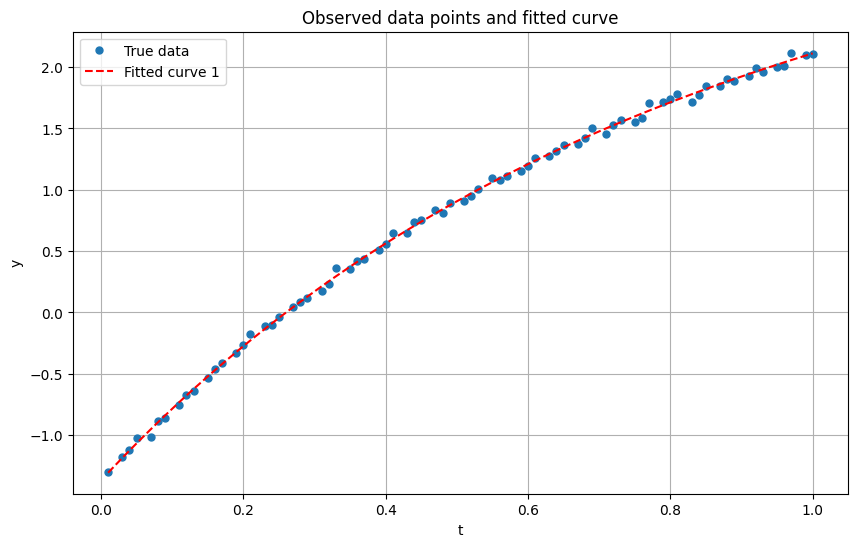

In [222]:
plt.figure(figsize=(10, 6))
plt.plot(t, y,'o', label="True data", markersize = 5) 
plt.plot(t, y_fit_1, label="Fitted curve 1", color = 'red', linestyle = '--')
plt.xlabel("t")
plt.ylabel("y")
plt.title("Observed data points and fitted curve")
plt.legend()
plt.grid(True)
plt.show()